# Análise Comparativa dos Experimentos — MLflow

Este notebook consome o store local do MLflow (`./mlruns`) para consolidar os 15 experimentos (5 modelos × 3 técnicas de redução de dimensionalidade) em uma visão comparativa. Serve como base para a **Parte 5** da rubrica: "Consolidação Experimental e Seleção Final".

**Pré-requisito:** rodar `make experiment` ou `python scripts/run_full_experiment.py` antes.

In [1]:
import matplotlib.pyplot as plt
import mlflow
import pandas as pd
import seaborn as sns

from cardio_ml.config import MLFLOW_EXPERIMENT_NAME, MLFLOW_TRACKING_URI

sns.set_theme(style="whitegrid")
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT_NAME)
runs = mlflow.search_runs(experiment_ids=[exp.experiment_id], output_format="pandas")
print(f"Runs totais: {len(runs)}")
runs = runs[runs["status"] == "FINISHED"].copy()
print(f"Runs concluídos: {len(runs)}")

Runs totais: 16
Runs concluídos: 16


In [2]:
summary_cols = [
    "tags.mlflow.runName",
    "tags.model_family",
    "tags.dim_technique",
    "metrics.cv.mean",
    "metrics.tech.f1",
    "metrics.tech.roc_auc",
    "metrics.tech.precision",
    "metrics.tech.recall",
    "metrics.biz.expected_cost_per_case",
    "metrics.train.fit_seconds",
]
summary = runs[summary_cols].rename(
    columns=lambda c: c.replace("tags.", "").replace("metrics.", "")
)
summary = summary.sort_values("tech.f1", ascending=False).reset_index(drop=True)
summary

,mlflow.runName,model_family,dim_technique,cv.mean,tech.f1,tech.roc_auc,tech.precision,tech.recall,biz.expected_cost_per_case,train.fit_seconds
0,xgboost__raw,xgboost,none,0.726720,0.725980,0.800651,0.753498,0.700400,0.863071,93.442562
1,random_forest__raw,random_forest,none,0.723578,0.722193,0.796287,0.749808,0.696541,0.874357,334.062956
2,decision_tree__raw,decision_tree,none,0.720980,0.719837,0.783742,0.733175,0.706975,0.860714,27.379265
3,xgboost__pca,xgboost,pca,0.718377,0.713527,0.785716,0.726693,0.700829,0.879214,123.669467
4,random_forest__pca,random_forest,pca,0.709808,0.707065,0.769967,0.705305,0.708834,0.875500,1383.689540
5,logistic_regression__raw,logistic_regression,none,0.708004,0.702240,0.778781,0.732495,0.674385,0.936643,17.803973
6,logistic_regression__raw,logistic_regression,none,0.708004,0.702240,0.778781,0.732495,0.674385,0.936643,8.210359
7,logistic_regression__pca,logistic_regression,pca,0.706945,0.701460,0.774471,0.724201,0.680103,0.928714,15.450096
8,decision_tree__pca,decision_tree,pca,0.681523,0.665704,0.744476,0.710877,0.625929,1.061857,113.475296
9,xgboost__lda,xgboost,lda,0.644530,0.633460,0.696919,0.649639,0.618067,1.120857,70.818929


## Comparação por família de modelo e técnica de redução

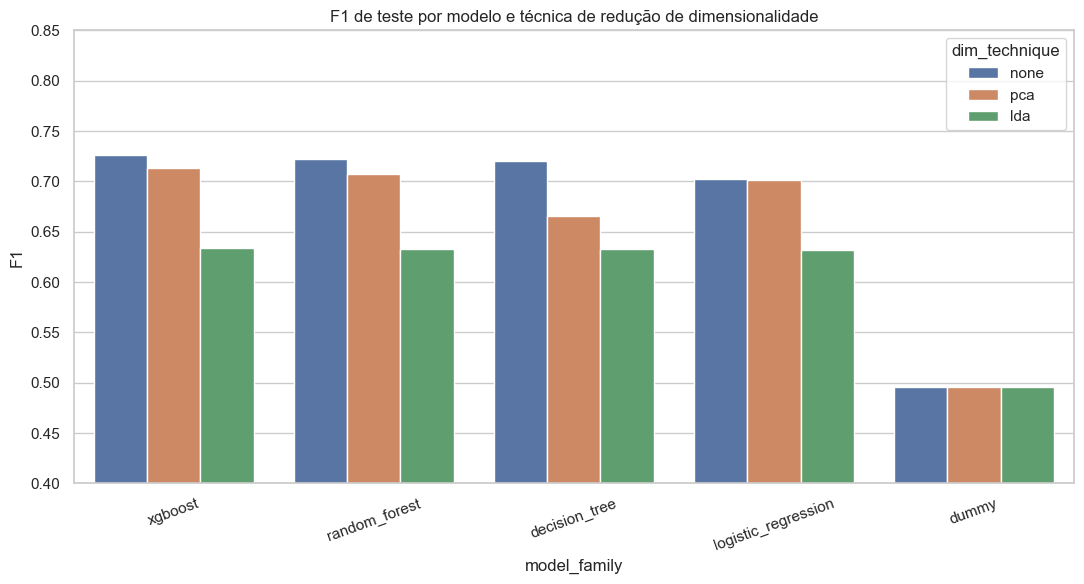

In [3]:
plot_df = summary.dropna(subset=["tech.f1"]).copy()
plot_df["dim_technique"] = plot_df["dim_technique"].fillna("none")

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=plot_df,
    x="model_family",
    y="tech.f1",
    hue="dim_technique",
    ax=ax,
)
ax.set_title("F1 de teste por modelo e técnica de redução de dimensionalidade")
ax.set_ylabel("F1")
ax.set_ylim(0.4, 0.85)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Trade-off performance × custo computacional

Modelo ideal fica no canto superior esquerdo: alto F1, baixo tempo de treino.

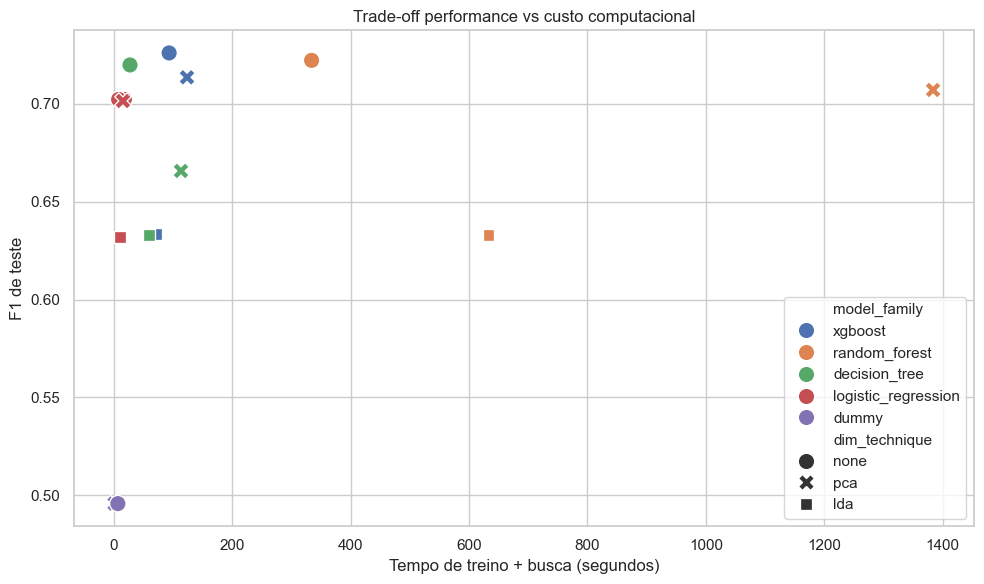

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = sns.scatterplot(
    data=plot_df,
    x="train.fit_seconds",
    y="tech.f1",
    hue="model_family",
    style="dim_technique",
    s=140,
    ax=ax,
)
ax.set_xlabel("Tempo de treino + busca (segundos)")
ax.set_ylabel("F1 de teste")
ax.set_title("Trade-off performance vs custo computacional")
plt.tight_layout()
plt.show()

## Impacto da redução de dimensionalidade

Comparação pareada: para cada modelo, qual técnica (`none`, `pca`, `lda`) venceu?

In [5]:
pivot = plot_df.pivot_table(
    index="model_family",
    columns="dim_technique",
    values="tech.f1",
    aggfunc="max",
)
pivot

dim_technique,lda,none,pca
model_family,,,
decision_tree,0.632915,0.719837,0.665704
dummy,0.495756,0.495756,0.495756
logistic_regression,0.632066,0.702240,0.701460
random_forest,0.632969,0.722193,0.707065
xgboost,0.633460,0.725980,0.713527


## Próximos passos

Com este ranking em mãos, rode `python scripts/select_final_model.py` para registrar automaticamente o modelo vencedor no MLflow Model Registry, aplicando o score composto (60% F1, 25% custo esperado, 15% tempo de treino).